# Plane wave scattered by a Taylor vortex

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
from scipy import fft

from vortex2dscatter import VortexScatter2D, helmholtz2d_truncated_greenf
from clairgabard_ref import ClairGabardRef

## Divergence of the Born series

In [ ]:
def build_taylor(wavelength, mach, domain, mesh):
    return VortexScatter2D(wavelength).init_mesh(domain, mesh).add_taylor_vortex(mach).complete()


def born_history(wavelength, mach, domain, mesh, niter):
    sol = build_taylor(wavelength, mach, domain, mesh)
    for _ in range(niter):
        sol.born_step()
    return np.asarray(sol.residual, dtype=float)


def gmres_history(wavelength, mach, domain, mesh, niter, tol=1e-20):
    sol = build_taylor(wavelength, mach, domain, mesh)
    sol.solve(maxiter=niter, tol=tol)
    return np.asarray(sol.residual, dtype=float)


residual_cases = [
    dict(wavelength=4.0, mach=0.125, domain=5.0, mesh=20, niter=50, xlim=(0, 51), ylim=(1e-17, 1e2), xticks=np.arange(0, 60, 10)),
    dict(wavelength=4.0, mach=0.125, domain=5.0, mesh=60, niter=50, xlim=(0, 51), ylim=(1e-9, 1e2), xticks=np.arange(0, 60, 10)),
    dict(wavelength=1.0, mach=0.25, domain=5.0, mesh=40, niter=150, xlim=(0, 151), ylim=(1e-17, 1e2), xticks=np.arange(0, 180, 30)),
    dict(wavelength=1.0, mach=0.25, domain=5.0, mesh=120, niter=150, xlim=(0, 151), ylim=(1e-11, 1e4), xticks=np.arange(0, 180, 30)),
]

residual_results = []
for case in residual_cases:
    born = born_history(case["wavelength"], case["mach"], case["domain"], case["mesh"], case["niter"])
    gmres = gmres_history(case["wavelength"], case["mach"], case["domain"], case["mesh"], case["niter"])
    residual_results.append((case, born, gmres))

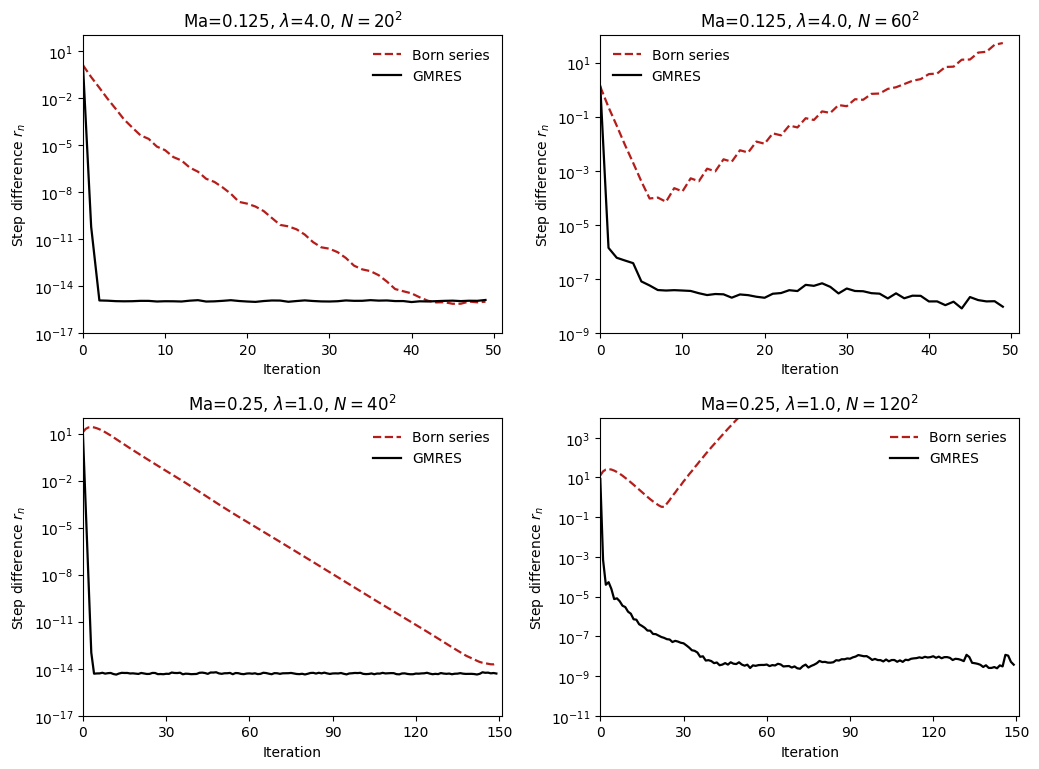

In [5]:
fig, axs = plt.subplots(2, 2, figsize=(10.5, 7.8))
for ax, (case, born, gmres) in zip(axs.flat, residual_results):
    ax.semilogy(born, lw=1.6, color="#b51d1a", ls="--", label="Born series")
    ax.semilogy(gmres, lw=1.6, color="black", label="GMRES")
    ax.set_xlim(case["xlim"])
    ax.set_ylim(case["ylim"])
    ax.set_xticks(case["xticks"])
    ax.set_xlabel("Iteration")
    ax.set_ylabel(r"Step difference $r_n$")
    ax.set_title(rf"Ma={case['mach']}, $\lambda$={case['wavelength']}, $N={case['mesh']}^2$")
    ax.legend(frameon=False)
fig.tight_layout()

## Directivity plot for verification

In [ ]:
def padded_scattered_field(sol, margin=15.0, stride=1):
    n = sol.mesh_size
    n_ext = int(margin / sol.h + 1)
    ntot = n + 2 * n_ext

    x0 = sol.x[0, 0] - n_ext * sol.h
    x = x0 + np.arange(ntot) * sol.h
    X, Y = np.meshgrid(x, x, indexing="ij")

    source = np.zeros((ntot, ntot), dtype=np.complex128)
    source[n_ext : n_ext + n, n_ext : n_ext + n] = sol._kernel_p

    length = (ntot - 1) * sol.h
    pad_n = 4 * ntot
    k = fft.fftfreq(pad_n, sol.h) * 2 * np.pi
    KX, KY = np.meshgrid(k, k, indexing="ij")
    green_hat = helmholtz2d_truncated_greenf(1.5 * length, sol.k, np.sqrt(KX**2 + KY**2))
    field = fft.ifft2(green_hat * fft.fft2(source, s=(pad_n, pad_n), workers=-1), workers=-1)[:ntot, :ntot]

    return X[::stride, ::stride], Y[::stride, ::stride], field[::stride, ::stride]


benchmark_cases = [
    dict(name="m0125_l4", wavelength=4.0, mach=0.125, domain=5.0, mesh=80, maxiter=50, radial_points=2000, rmax=6.0, modes=50, low=-np.pi, high=np.pi, ntheta=361, field_vlim=0.3, field_stride=1),
    dict(name="m025_l1", wavelength=1.0, mach=0.25, domain=5.0, mesh=180, maxiter=80, radial_points=2000, rmax=6.0, modes=50, low=-2*np.pi/3, high=2*np.pi/3, ntheta=321, field_vlim=3.3, field_stride=1),
    dict(name="m005_l16", wavelength=16.0, mach=0.125, domain=6.0, mesh=60, maxiter=20, radial_points=1200, rmax=16.0, modes=50, low=-np.pi, high=np.pi, ntheta=361, field_vlim=0.012, field_stride=1),
    dict(name="m025_l05", wavelength=0.5, mach=0.25, domain=6.0, mesh=360, maxiter=20, radial_points=2000, rmax=6.0, modes=50, low=-np.pi/2, high=np.pi/2, ntheta=321, field_vlim=2.7, field_stride=2),
]

benchmark_results = []
for case in benchmark_cases:
    sol = build_taylor(case["wavelength"], case["mach"], case["domain"], case["mesh"])
    sol.solve(maxiter=case["maxiter"], tol=1e-10)
    theta, direct = sol.directivity(radius=8.0, ntheta=case["ntheta"], low=case["low"], high=case["high"])
    ref = ClairGabardRef(case["wavelength"], case["mach"], case["radial_points"], rmax=case["rmax"], modes=case["modes"])
    theta_ref, direct_ref = ref.predict_farfield(radius=8.0, ntheta=1001)
    Xs, Ys, Ps = padded_scattered_field(sol, stride=case["field_stride"])
    benchmark_results.append(dict(case=case, theta=theta, direct=direct, theta_ref=theta_ref, direct_ref=direct_ref, sol=sol, field=(Xs, Ys, Ps)))


The directivity is evaluated on a circle of radius $r=8$ and plotted as $|p_s|\sqrt{r}$. Results compared with the semi-spectral method from Clair et al. (2018)

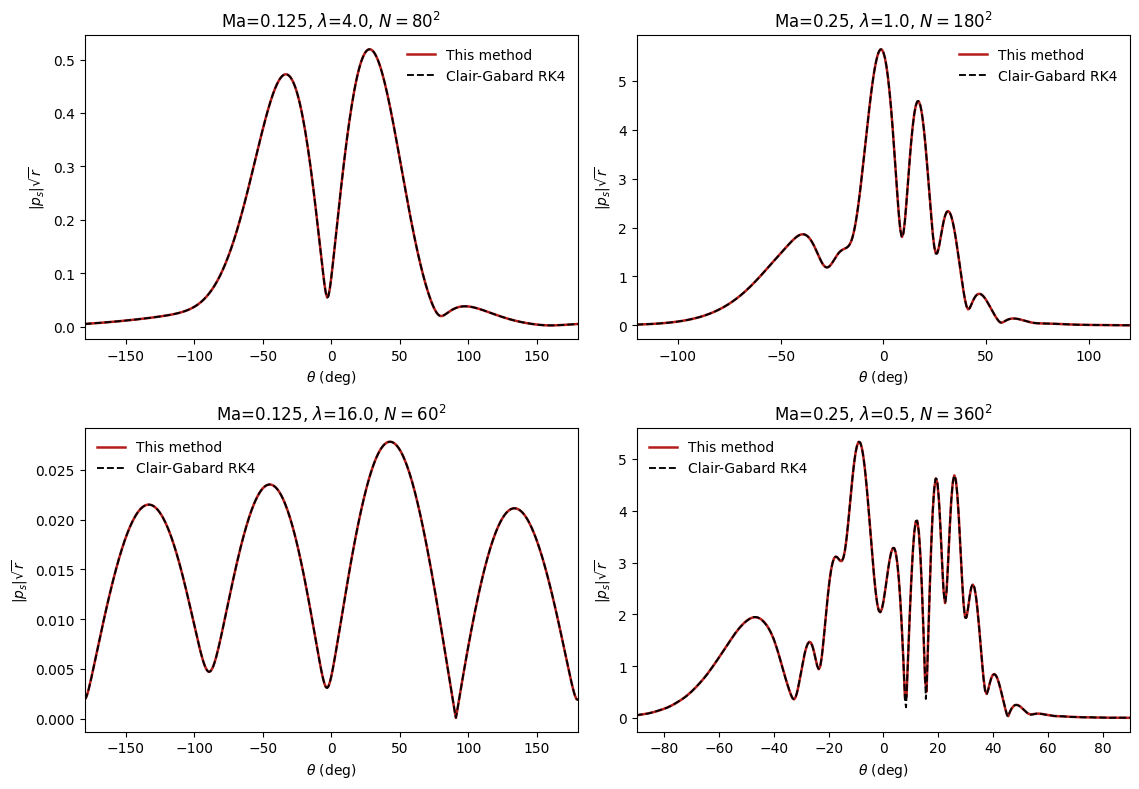

In [10]:
fig, axs = plt.subplots(2, 2, figsize=(11.5, 8.0))
for ax, result in zip(axs.flat, benchmark_results):
    case = result["case"]
    scale = np.sqrt(8.0)
    ax.plot(result["theta"] * 180 / np.pi, np.abs(result["direct"]) * scale, color="#b51d1a", lw=1.8, label="This method")
    ax.plot(result["theta_ref"] * 180 / np.pi, np.abs(result["direct_ref"]) * scale, color="black", lw=1.35, ls="--", label="Clair-Gabard RK4")
    ax.set_xlim(case["low"] * 180 / np.pi, case["high"] * 180 / np.pi)
    ax.set_xlabel(r"$\theta$ (deg)")
    ax.set_ylabel(r"$|p_s|\sqrt{r}$")
    ax.set_title(rf"Ma={case['mach']}, $\lambda$={case['wavelength']}, $N={case['mesh']}^2$")
    ax.legend(frameon=False, loc="best")
fig.tight_layout()


### Scattered waves

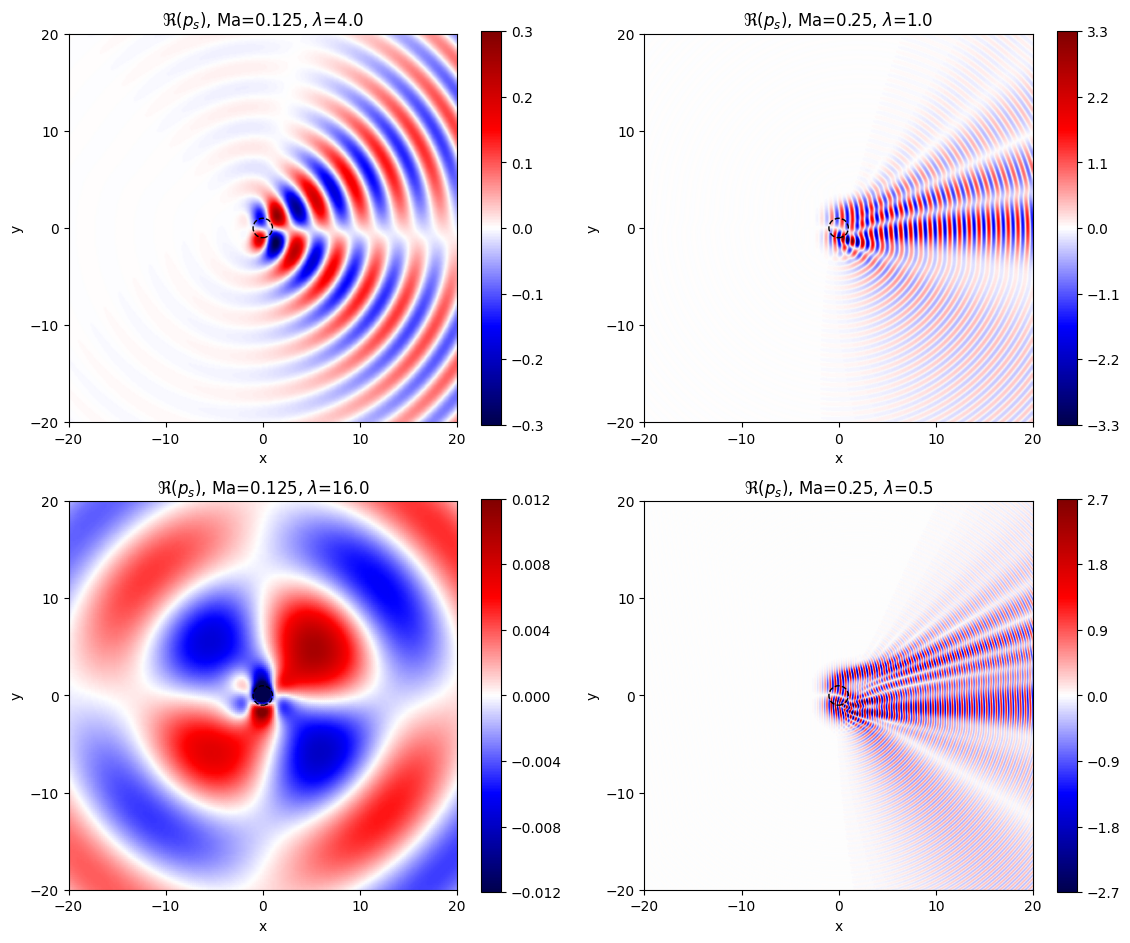

In [11]:
fig, axs = plt.subplots(2, 2, figsize=(11.5, 9.5))
for ax, result in zip(axs.flat, benchmark_results):
    case = result["case"]
    Xs, Ys, Ps = result["field"]
    vmax = case["field_vlim"]
    im = ax.pcolormesh(Xs, Ys, Ps.real, cmap="seismic", shading="gouraud", vmin=-vmax, vmax=vmax, rasterized=True, edgecolors="none")
    ax.add_patch(Ellipse((0, 0), 2, 2, fill=False, ls="--", lw=1.0, color="black"))
    ax.set_aspect("equal")
    ax.set_xlim(-20, 20)
    ax.set_ylim(-20, 20)
    ax.set_xticks(np.arange(-20, 21, 10))
    ax.set_yticks(np.arange(-20, 21, 10))
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_title(rf"$\Re(p_s)$, Ma={case['mach']}, $\lambda$={case['wavelength']}")
    fig.colorbar(im, ax=ax, ticks=np.linspace(-vmax, vmax, 7)).solids.set_rasterized(True)
fig.tight_layout()
